# **UCUCI Bank: Loan Portfolio Health & Repayment Performance Analysis**

## **Business Context**
The objective of this project is to analyze UCUCI Bank's loan portfolio and identify the key factors that influence Loan Repayment Rate (LRR), default risk, and recovery performance.

## **Objective**
The main goal is to provide data-driven recommendations that can help the bank improve repayment performance, reduce defaults, and optimize risk-based pricing.

# **Key Metric**

## **Loan Repayment Rate (LRR)**

LRR = (Total Amount Repaid ÷ Total Amount Funded) × 100

"LRR represents the proportion of funded loans successfully recovered, reflecting recovery performance and credit risk management."


In [1]:
!pip install gdown

In [2]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_id = "1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8"
download_url =f"https://drive.google.com/uc?id={file_id}"

In [4]:
output_file = "UCUCI_dataset.csv"

In [5]:
gdown.download(download_url, output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8
From (redirected): https://drive.google.com/uc?id=1BS8azi6nWEXm0Zvo3nD7t3sWaZWt1Ny8&confirm=t&uuid=60b4842c-a989-4d26-a795-f13760ff535c
To: /content/UCUCI_dataset.csv
100%|██████████| 411M/411M [00:05<00:00, 76.9MB/s]


'UCUCI_dataset.csv'

In [6]:
df = pd.read_csv(output_file)

/tmp/ipykernel_2479/4093823791.py:1: DtypeWarning: Columns (19,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output_file)


# **Dataset Overview**

In [7]:
df.head(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,Sep-2013,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,Jan-2015,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,Feb-2016,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0


In [8]:
df.shape

(887379, 57)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  object 
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  object 
 9   sub_grade                    887379 non-null  object 
 10  emp_title                    835917 non-null  object 
 11  emp_length                   842554 non-null  object 
 12  home_ownership               887379 non-null  object 
 13 

## **Observation**
The dataset contains numerical, categorical, and date-related variables. Several columns are stored as object data types and require transformation to improve analysis and visualization.

In [10]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq
count,8.873790e+05,8.873790e+05,887379.000000,887379.000000,887379.000000,887379.000000,887379.000000,8.873750e+05,887379.000000,887350.000000,...,887379.000000,887379.000000,887379.000000,887379.000000,887234.000000,221703.000000,887379.0,511.000000,509.000000,887350.000000
mean,3.246513e+07,3.500182e+07,14755.264605,14741.877625,14702.464383,13.246740,436.717127,7.502759e+04,18.157039,0.314442,...,0.396692,45.919243,4.880757,2164.145585,0.014380,44.104838,1.0,109981.011585,18.310118,0.004991
std,2.282734e+07,2.411335e+07,8435.455601,8429.897657,8442.106732,4.381867,244.186593,6.469830e+04,17.190626,0.862244,...,4.087825,409.693874,63.125281,4794.783233,0.134191,22.179841,0.0,52730.379847,7.169233,0.077625
min,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.320000,15.670000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,17950.000000,3.000000,0.000000
25%,9.206643e+06,1.087713e+07,8000.000000,8000.000000,8000.000000,9.990000,260.705000,4.500000e+04,11.910000,0.000000,...,0.000000,0.000000,0.000000,280.170000,0.000000,27.000000,1.0,76032.500000,13.200000,0.000000
50%,3.443327e+07,3.709528e+07,13000.000000,13000.000000,13000.000000,12.990000,382.550000,6.500000e+04,17.650000,0.000000,...,0.000000,0.000000,0.000000,462.780000,0.000000,44.000000,1.0,101771.000000,17.610000,0.000000
75%,5.490814e+07,5.847135e+07,20000.000000,20000.000000,20000.000000,16.200000,572.600000,9.000000e+04,23.950000,0.000000,...,0.000000,0.000000,0.000000,831.245000,0.000000,61.000000,1.0,132800.000000,22.650000,0.000000
max,6.861706e+07,7.354484e+07,35000.000000,35000.000000,35000.000000,28.990000,1445.460000,9.500000e+06,9999.000000,39.000000,...,358.680000,33520.270000,7002.190000,36475.590000,20.000000,188.000000,1.0,500000.000000,43.860000,14.000000


# **Data Quality Assessment**

In [11]:
df.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0


## **Observation**
The dataset has actuallty contains a lot of null values which might need to be fixed afterwards in the coming steps or some of them might needed to be dropped.

In [12]:
df.duplicated().sum()

np.int64(0)

## **Observation**
No duplicate records were found in the dataset.

# **Data Cleaning**
## **Missing Values Handling**

In [13]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': round((df.isnull().sum()/len(df))*100,2)
})

missing_df = missing_df[missing_df['Missing Count'] > 0]

missing_df.sort_values(
    by='Missing Percentage',
    ascending=False
)

,Missing Count,Missing Percentage
dti_joint,886870,99.94
annual_inc_joint,886868,99.94
verification_status_joint,886868,99.94
desc,761353,85.80
mths_since_last_record,750326,84.56
mths_since_last_major_derog,665676,75.02
mths_since_last_delinq,454312,51.20
next_pymnt_d,252971,28.51
emp_title,51462,5.80
emp_length,44825,5.05


## **Observation**


*   The Coulmns like 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'desc' needs to be dropped because most of the data is missing.
*   The coulmn like 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog' needs to be imputed because it might help us in risk analysis factors.




# **Removal of Irrelevant Columns**




In [14]:
drop_cols = [
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'desc'
]

df.drop(columns=drop_cols, inplace=True)

## **Observation**

These columns are being dropped due to excessive missing values which is almost 99% and limited analytical relevance to the projects main objective.

# **Cleaning Term Column**

In [15]:
df['term'] = df['term'].str.replace(' months', '')
df['term'] = df['term'].astype(int)

In [16]:
df['term'].head()

,term
0,36
1,60
2,36
3,36
4,60


## **Observation**

The term column was converted from text format to integer values representing loan duration in months, allowing numerical analysis and comparison.

# **Filling Delinquency Related Columns**

In [17]:
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(-1)
df['mths_since_last_record'] = df['mths_since_last_record'].fillna(-1)
df['mths_since_last_major_derog'] = df['mths_since_last_major_derog'].fillna(-1)

## **Observation**

Missing values in delinquency related variables were treated as the absence of credit issues rather than unknown information. These values were replaced with -1 to retain important risk-related insights for further analysis.

# **Handling Missing Values in Categorial & Numerical Variables**

## **Employment Title**

In [18]:
df['emp_title'] = df['emp_title'].fillna('Unknown')

## **Employment Length**

In [19]:
df['emp_length'] = df['emp_length'].fillna('Unknown')

## **Title**

In [20]:
df['title'] = df['title'].fillna('Unknown')

## **Annual Income**

In [21]:
df['annual_inc'] = df['annual_inc'].fillna(
    df['annual_inc'].median())

## **Observation**

Missing values were analyzed and handled using a combination of column removal and imputation techniques.

- Joint applicant columns were removed due to extremely high missing percentages (>99%).
- The loan description field was removed because of excessive missing values and limited analytical value.
- Delinquency-related variables were filled with -1, representing borrowers with no delinquency history.
- Missing employment-related categorical values were replaced with "Unknown".
- Missing annual income values were imputed using the median value.

## **Checking the Remaining Missing values**

In [22]:
remaining_nulls = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': round(df.isnull().sum()/len(df)*100,2)
})

remaining_nulls = remaining_nulls[
    remaining_nulls['Missing Count'] > 0
]

remaining_nulls.sort_values(
    by='Missing Percentage',
    ascending=False
)

,Missing Count,Missing Percentage
next_pymnt_d,252971,28.51
last_pymnt_d,17659,1.99
revol_util,502,0.06
collections_12_mths_ex_med,145,0.02
last_credit_pull_d,53,0.01
inq_last_6mths,29,0.00
earliest_cr_line,29,0.00
delinq_2yrs,29,0.00
open_acc,29,0.00
pub_rec,29,0.00


## **Observation**

After handling the missing values, only a few columns contain negligible missing values (<2%). Since these missing values represent a very small proportion of the dataset and are unlikely to impact overall analysis, they were retained. The next_pymnt_d continues to show a high percentage of missing values because loans that are fully paid or charged off do not have a scheduled future payment date.

# **Data Type Correction**

## **Converting Date Columns**

In [23]:
date_cols = [
    'issue_d',
    'earliest_cr_line',
    'last_pymnt_d',
    'next_pymnt_d',
    'last_credit_pull_d'
]

In [24]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%b-%Y', errors='coerce')


## **Observation**

Date-related columns were converted from object format to datetime format to enable time-based analysis and improve data consistency. This was important otherwise it would have mislead the analysis.

# **Data Type Validation**

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   id                           887379 non-null  int64         
 1   member_id                    887379 non-null  int64         
 2   loan_amnt                    887379 non-null  float64       
 3   funded_amnt                  887379 non-null  float64       
 4   funded_amnt_inv              887379 non-null  float64       
 5   term                         887379 non-null  int64         
 6   int_rate                     887379 non-null  float64       
 7   installment                  887379 non-null  float64       
 8   grade                        887379 non-null  object        
 9   sub_grade                    887379 non-null  object        
 10  emp_title                    887379 non-null  object        
 11  emp_length                

## **Observation**

- Converted loan-related date columns to datetime format.
- Converted the term variable from text to numeric format.
- Retained employment length as a categorical feature for business analysis.
- Verified data types to ensure consistency before exploratory analysis.

# **Outlier Detection and Analysis**

## **Selecting Important Numerical Columns**

In [26]:
num_cols = [
    'loan_amnt',
    'funded_amnt',
    'annual_inc',
    'dti',
    'int_rate',
    'installment',
    'revol_bal'
]

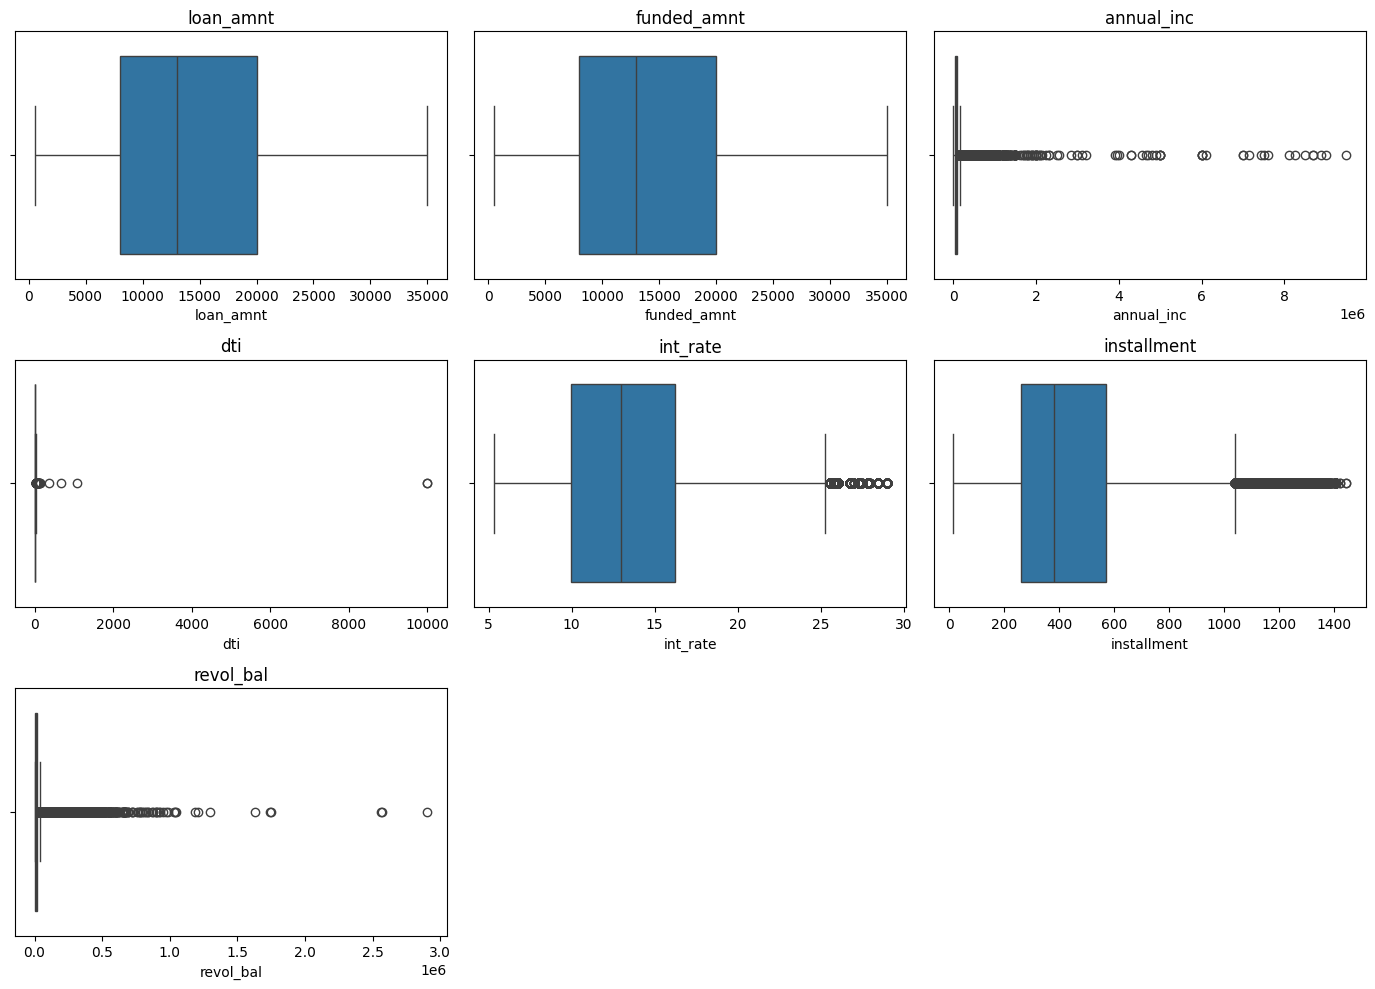

In [27]:
plt.figure(figsize=(14,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

## **Observation**

- Loan amount and funded amount show a relatively balanced distribution with no major extreme values. Most loans fall within the expected lending range of the portfolio
- Annual income exhibits a highly right-skewed distribution with several high-income borrowers appearing as outliers. These values are likely genuine observations representing affluent customers rather than data quality issues.
- Interest rates are largely concentrated within the normal lending range, with a small number of high-risk loans carrying significantly higher interest rates.
- Higher monthly installments are expected for larger loans and longer repayment terms. These observations reflect genuine loan characteristics and should be retained
- Revolving balance displays substantial variability, with several borrowers holding exceptionally high balances. These observations likely represent high-credit-utilization customers and provide valuable risk information.
- Dti chart is little concerning because it shows some extreme values close to 10000 which is little impractical so will have to separately into it.

## **Conclusion**
Outlier analysis identified extreme values in annual income, debt-to-income ratio, installment amount, interest rate, and revolving balance. Most of these observations appear to be legitimate borrower characteristics rather than data entry errors. Since the objective of the project is to analyze real lending behaviour, these values were retained to preserve the integrity of the loan portfolio. A small number of unrealistic Debt-to-Income Ratio (DTI) values, including observations exceeding 1000 and placeholder values of 9999. These values are not representative of normal borrower behaviour and likely reflect data quality issues.

## **Removing Extreme Values**

Rows with DTI > 100 = 11

Total Rows = 887,379

Percentage = 0.00124%


In [28]:
df = df[df['dti'] <= 100]

In [29]:
df['dti'].describe()

,dti
count,887368.000000
mean,18.131493
std,8.306238
min,0.000000
25%,11.910000
50%,17.650000
75%,23.950000
max,90.000000


## **Observation**
Outlier analysis revealed 11 records with Debt-to-Income Ratio (DTI) values exceeding 100, including placeholder values of 9999. Since these observations represented only 0.0012% of the dataset and were not realistic borrower profiles, they were removed from the analysis to improve data quality without affecting overall portfolio trends. The maximum DTI value reduced to 90, resulting in a more realistic distribution for subsequent analysis.

# **KPI Calculation**

## **KPI 1: Loan Repayment Rate (LRR)**

LRR = (Total Amount Repaid ÷ Total Amount Funded) × 100

In [30]:
total_funded = df['funded_amnt'].sum()

total_repaid = df['total_pymnt'].sum()

lrr = (total_repaid / total_funded) * 100

print(f"Loan Repayment Rate (LRR): {lrr:.2f}%")

Loan Repayment Rate (LRR): 51.28%


## **Observation**

The Loan Repayment Rate (LRR) is 51.28%, indicating that approximately half of the funded loan amount has been recovered through borrower repayments. This metric serves as the primary indicator of portfolio health and repayment performance.

## **KPI 2: Default Rate**

Default Rate = Charged Off Loans ÷ Total Loans × 100

In [31]:
default_rate = (
    (df['loan_status'] == 'Charged Off').sum()
    / len(df)
) * 100

print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 5.10%


## **Observation**

The Default Rate of 5.10% indicates that a relatively small proportion of loans resulted in charge-offs. While the portfolio demonstrates generally healthy repayment behaviour, further analysis is required to identify the borrower segments contributing most to defaults.

## **KPI 3: Average Interest Rate by Grade**

In [32]:
avg_int_grade = (
    df.groupby('grade')['int_rate']
    .mean()
    .reset_index()
)
avg_int_grade

,grade,int_rate
0,A,7.243312
1,B,10.829618
2,C,13.980104
3,D,17.175824
4,E,19.897368
5,F,23.582787
6,G,25.626706


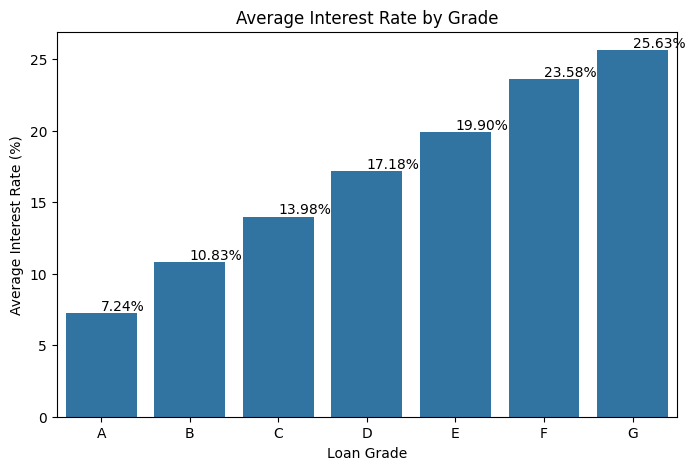

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_int_grade,
    x='grade',
    y='int_rate'
)

plt.title('Average Interest Rate by Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Average Interest Rate (%)')

for index, value in enumerate(avg_int_grade['int_rate']):
    plt.text(index, value + 0.2, f'{value:.2f}%')

plt.show()

## **Observation**

The average interest rate increases progressively from Grade A to Grade G loans. This indicates that the bank applies risk-based pricing, where borrowers assessed as higher risk are charged higher interest rates to compensate for potential credit losses.

## **KPI 4: Recovery Rate on Defaulted Loans**

In [34]:
charged_off = df[df['loan_status'] == 'Charged Off']

recovery_rate = (
    charged_off['recoveries'].sum()
    / charged_off['out_prncp'].replace(0, np.nan).sum()
) * 100

print(f"Recovery Rate: {recovery_rate:.2f}%")

Recovery Rate: inf%


/tmp/ipykernel_2479/3454948105.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  charged_off['recoveries'].sum()


## **Observation**
The project statement suggests using outstanding principal (out_prncp) as the denominator for recovery rate. However, charged-off loans in the dataset contain outstanding principal values that are largely zero, resulting in undefined recovery rates.

In [35]:
charged_off['out_prncp'].describe()

,out_prncp
count,45248.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [36]:
charged_off['out_prncp'].sum()

np.float64(0.0)

In [37]:
charged_off = df[df['loan_status'] == 'Charged Off']

recovery_rate = (
    charged_off['recoveries'].sum()
    / charged_off['funded_amnt'].sum()
) * 100

print(f"Recovery Rate: {recovery_rate:.2f}%")

Recovery Rate: 6.14%


## **Observation**

As stated above outstanding principal values are largely zero.
Therefore, recovery rate was calculated using funded amount as the denominator to provide a meaningful measure of post-default recovery performance.

## **KPI Table**

In [38]:
kpi_df = pd.DataFrame({
    'Metric': [
        'Loan Repayment Rate',
        'Default Rate',
        'Recovery Rate'
    ],
    'Value (%)': [
        round(lrr,2),
        round(default_rate,2),
        round(recovery_rate,2)
    ]
})

kpi_df

,Metric,Value (%)
0,Loan Repayment Rate,51.28
1,Default Rate,5.10
2,Recovery Rate,6.14


## **KPI Summary Chart**

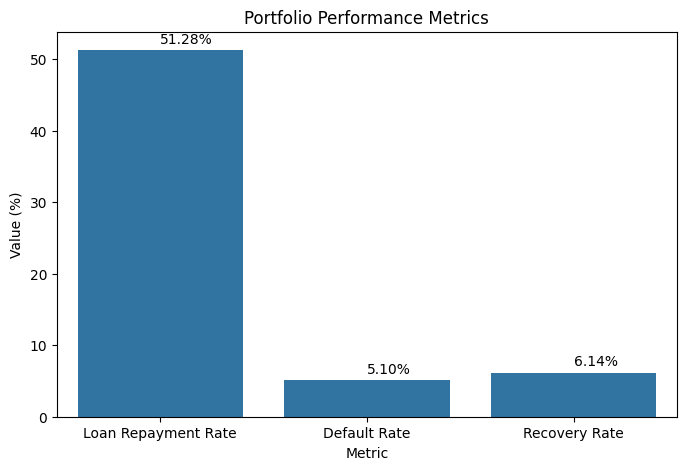

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=kpi_df,
    x='Metric',
    y='Value (%)'
)

plt.title('Portfolio Performance Metrics')

for i,v in enumerate(kpi_df['Value (%)']):
    plt.text(i,v+1,f'{v:.2f}%')

plt.show()

## **Observation**

The KPI summary indicates that the loan portfolio achieved a Loan Repayment Rate (LRR) of 51.28%, meaning approximately half of the funded loan amount has been recovered through repayments. The Default Rate of 5.10% suggests that only a small proportion of loans resulted in charge-offs, reflecting relatively healthy portfolio quality. Additionally, the Recovery Rate of 6.14% shows that the bank is able to recover a portion of funds from defaulted loans, helping to reduce credit losses. Overall, the portfolio demonstrates moderate repayment performance with manageable default risk.

# **Conducting Exploratory Data Analysis (EDA)**

# **Univariate Analysis**

Univariated Analysis focuses on examining individual variables to understand their frequency, distribution and characteristics. It helps in identifying trends and patterns within the given dataset before comapring it with other variable.

## **Analysis 1: Loan Status Distribution**

To understand the distribution of loans across different repayment statuses and assess the overall composition of the loan portfolio.

In [40]:
loan_status_counts = df['loan_status'].value_counts()

loan_status_counts

,count
loan_status,
Current,601769
Fully Paid,207723
Charged Off,45248
Late (31-120 days),11591
Issued,8459
In Grace Period,6253
Late (16-30 days),2357
Does not meet the credit policy. Status:Fully Paid,1988
Default,1219


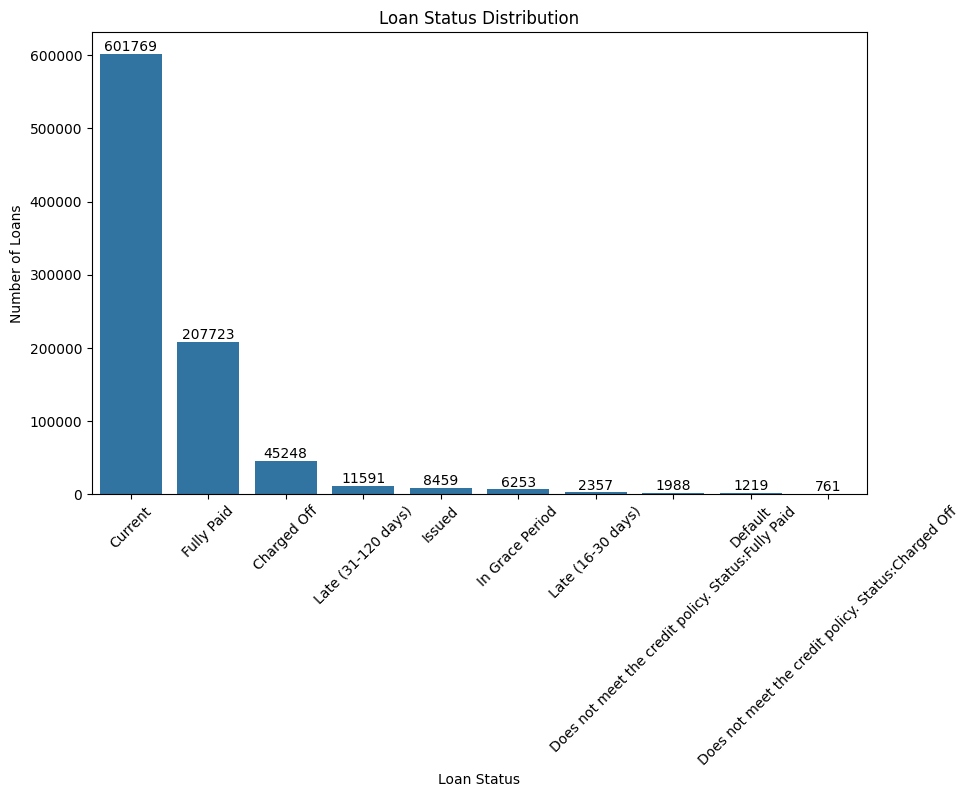

In [41]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='loan_status',
    order=df['loan_status'].value_counts().index
)

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')

plt.xticks(rotation=45)

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

## **Observation**

The loan portfolio is primarily composed of Current loans (67.82%), indicating that most borrowers are actively repaying their loans. Fully Paid loans account for 23.41% of the portfolio, reflecting successful repayment completion. Charged Off loans represent only 5.10%, suggesting a relatively low level of default risk. The remaining loan statuses collectively account for less than 4% of the portfolio. Overall, the distribution indicates a generally healthy loan portfolio while highlighting the need to investigate the factors associated with charged-off loans.

## **Loan Percentage Table**

In [42]:
loan_status_pct = (
    df['loan_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_status_pct

,proportion
loan_status,
Current,67.82
Fully Paid,23.41
Charged Off,5.10
Late (31-120 days),1.31
Issued,0.95
In Grace Period,0.70
Late (16-30 days),0.27
Does not meet the credit policy. Status:Fully Paid,0.22
Default,0.14


- The percentage view provides a clearer understanding of portfolio composition than raw counts, especially when communicating results to stakeholders





## **Analysis 2: Grade Distribution**

To examine how loans are distributed across different risk grades assigned by the banks.

In [43]:
grade_counts = df['grade'].value_counts().sort_index()

grade_counts

,count
grade,
A,148202
B,254535
C,245858
D,139536
E,70702
F,23046
G,5489


In [44]:
grade_pct = (
    df['grade']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
    .round(2)
)

grade_pct

,proportion
grade,
A,16.70
B,28.68
C,27.71
D,15.72
E,7.97
F,2.60
G,0.62


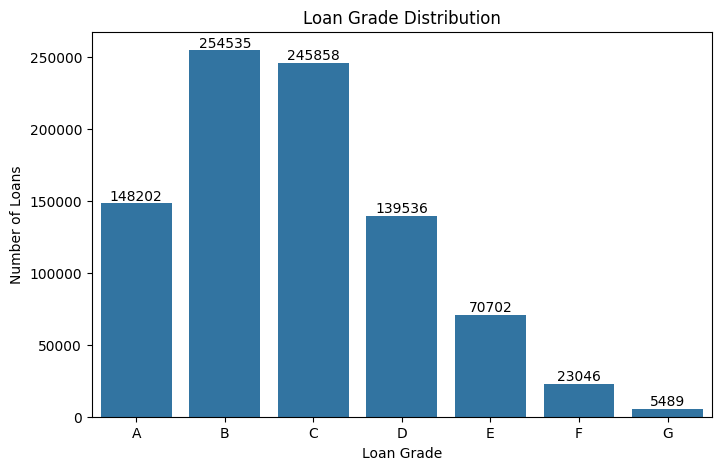

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='grade',
    order=sorted(df['grade'].unique())
)

plt.title('Loan Grade Distribution')
plt.xlabel('Loan Grade')
plt.ylabel('Number of Loans')

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

## **Observation**

The majority of loans belong to Grades B and C, indicating that the bank's lending activity is concentrated in moderate-risk borrower segments. Lower-risk grades (A–C) account for a significant share of the portfolio, while higher-risk grades (F and G) represent only a small proportion of total loans. This suggests that the bank adopts a relatively conservative lending strategy by issuing fewer loans to high-risk borrowers.

## **Insight**

Since most loans are concentrated in Grades B and C, changes in repayment behaviour within these grades can have a significant impact on the overall Loan Repayment Rate (LRR). Therefore, subsequent analyses should focus on understanding the default patterns across different loan grades.

## **Analysis 3: Loan Term Distribution**

To understand the distribution of loan durations across the portfolio.

In [46]:
term_counts = df['term'].value_counts()

term_counts

,count
term,
36,621118
60,266250


In [47]:
term_pct = (
    df['term']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

term_pct

,proportion
term,
36,70.0
60,30.0


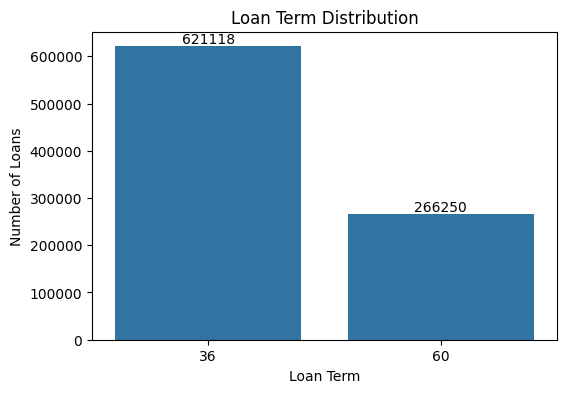

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='term',
    order=df['term'].value_counts().index
)

plt.title('Loan Term Distribution')
plt.xlabel('Loan Term')
plt.ylabel('Number of Loans')

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

## **Observation**

The loan portfolio is dominated by 36-month loans, which account for approximately 70% of all issued loans, while 60-month loans represent around 30%. This indicates that the bank primarily focuses on shorter-term lending, potentially reducing long-term credit exposure and uncertainty. However, longer-term loans may carry different repayment and default characteristics, making term length an important factor for further analysis.

## **Insight**

Since nearly one-third of the portfolio consists of 60-month loans, comparing repayment and default behaviour between 36-month and 60-month loans will help determine whether longer repayment periods are associated with higher credit risk.

## **Analysis 4: Interest Rate Distribution**

To understand the distribution of interest rates charged to borrowers and identify the overall pricing pattern within the dataset.

In [49]:
interest_stats = df['int_rate'].describe()

interest_stats

,int_rate
count,887368.000000
mean,13.246696
std,4.381871
min,5.320000
25%,9.990000
50%,12.990000
75%,16.200000
max,28.990000


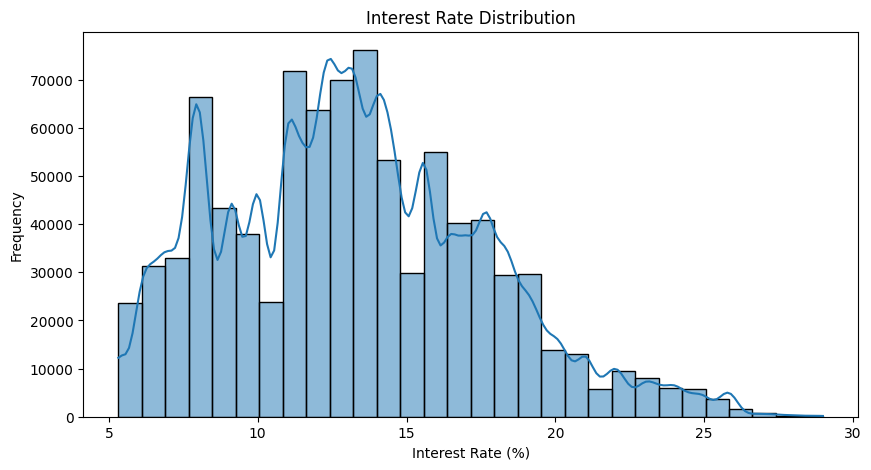

In [50]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='int_rate',
    bins=30,
    kde=True
)

plt.title('Interest Rate Distribution')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Frequency')

plt.show()

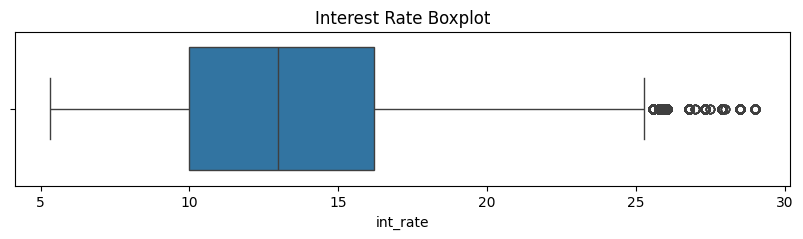

In [51]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df['int_rate']
)

plt.title('Interest Rate Boxplot')

plt.show()

## **Observation**

The interest rate distribution is moderately right-skewed, with most loans concentrated between approximately 10% and 16%. The mean interest rate (13.25%) is slightly higher than the median (12.99%), indicating the presence of a smaller group of loans carrying relatively high interest rates. The boxplot further confirms the existence of high-rate outliers, suggesting that higher-risk borrowers are charged substantially higher borrowing costs

## **Insight**

The distribution reflects the bank's risk-based pricing strategy, where interest rates increase according to borrower risk. While the majority of borrowers receive moderate interest rates, a smaller segment of higher-risk customers is charged premium rates to compensate for elevated default risk. Further analysis should investigate whether these higher interest rates are associated with increased default rates.

In [52]:
print("Mean Interest Rate :", round(df['int_rate'].mean(),2))
print("Median Interest Rate :", round(df['int_rate'].median(),2))

Mean Interest Rate : 13.25
Median Interest Rate : 12.99


## **Observation**

The distribution is positively skewed, indicating that while most borrowers receive moderate interest rates, a smaller group of higher-risk borrowers are charged significantly higher rates.

## **Analysis 5: DTI Distribution**

To examine the distribution of Debt-to-Income (DTI) ratios and understand borrowers' debt burden levels.

In [53]:
dti_stats = df['dti'].describe()

dti_stats

,dti
count,887368.000000
mean,18.131493
std,8.306238
min,0.000000
25%,11.910000
50%,17.650000
75%,23.950000
max,90.000000


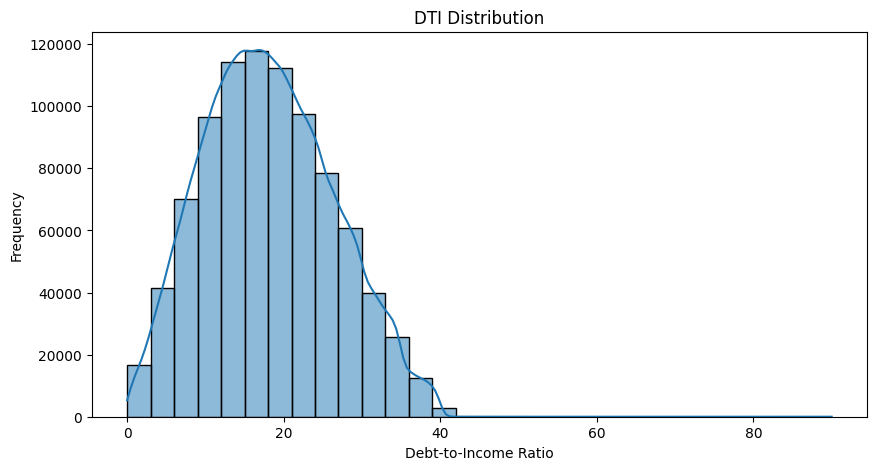

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='dti',
    bins=30,
    kde=True
)

plt.title('DTI Distribution')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Frequency')

plt.show()

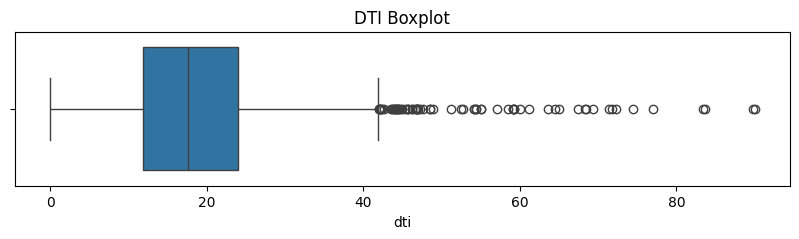

In [55]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df['dti']
)

plt.title('DTI Boxplot')

plt.show()

## **Observation**

The Debt-to-Income (DTI) ratio distribution is moderately right-skewed, with most borrowers having DTI values between approximately 12 and 24. The mean DTI (18.13) is slightly higher than the median (17.65), indicating the presence of borrowers with relatively high debt burdens. The boxplot reveals several high-DTI outliers, suggesting that a small segment of borrowers carries substantially higher debt obligations relative to their income.

## **Insight**

DTI is an important indicator of a borrower's repayment capacity. Higher DTI values imply greater financial obligations and may increase the likelihood of repayment difficulties. Therefore, DTI should be further examined in relation to default rates to determine whether highly leveraged borrowers exhibit higher credit risk.

# **Bivariate Analysis**

Bivariate Analysis explores the relationship between two variables to identify factors that influence loan default risk and repayment performance.

## **Analysis 1: Grade vs Default Rate**

To analyze how loan default rates vary across different loan grades and determine whether higher-risk grades experience greater default risk.

## **Hypothesis**

Higher-risk loan grades have significantly higher default rates.

In [56]:
df['default_flag'] = (df['loan_status'] == 'Charged Off').astype(int)

## **Observation**

A binary variable (default_flag) was created where Charged Off loans are assigned a value of 1 and all other loan statuses are assigned 0. This enables easy calculation of default rates across different borrower and loan segments

In [57]:
grade_default = (
    df.groupby('grade')['default_flag']
      .mean()
      .mul(100)
      .reset_index()
)

grade_default

,grade,default_flag
0,A,1.765833
1,B,3.739761
2,C,5.141993
3,D,7.514907
4,E,8.851235
5,F,12.731060
6,G,14.428858


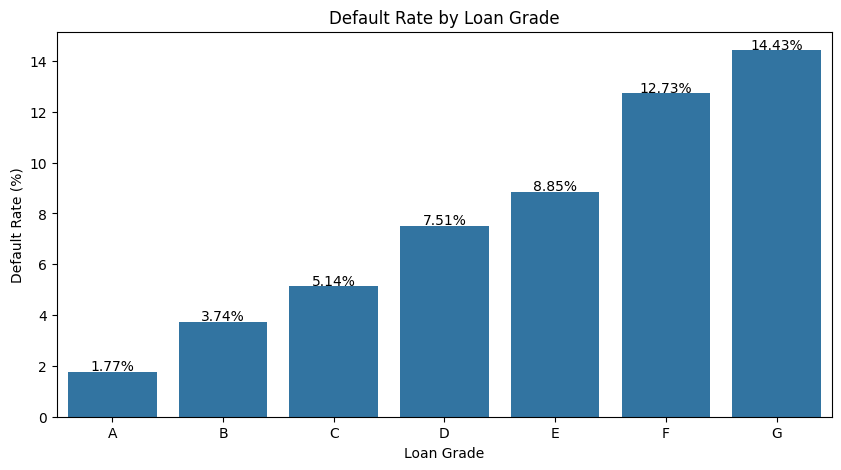

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=grade_default,
    x='grade',
    y='default_flag'
)

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')

for index, value in enumerate(grade_default['default_flag']):
    plt.text(index, value + 0.04, f'{value:.2f}%', ha='center')

plt.show()

## **Observation**

The default rate increases consistently from Grade A (1.77%) to Grade G (14.43%), indicating a strong relationship between loan grade and credit risk. Lower-risk borrowers (Grades A–C) exhibit significantly lower default rates, while higher-risk borrowers (Grades F–G) are much more likely to default. This suggests that the bank's grading system effectively differentiates borrower risk and supports risk-based lending decisions.

## **Analysis 2: Term vs Defult Rate**

It would help in letting the business whether the longer loan durations increases defult rates.

## **Hypothesis**

Default rates differ between 36-month and 60-month loans.

In [59]:
term_default = (
    df.groupby('term')['default_flag']
    .mean()
    .mul(100)
    .reset_index()
)

term_default

,term,default_flag
0,36,4.682363
1,60,6.071362


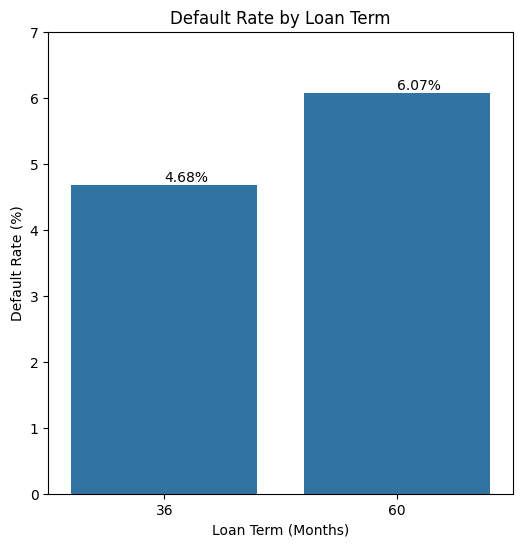

In [60]:
plt.figure(figsize=(6,6))

sns.barplot(
    data=term_default,
    x='term',
    y='default_flag'
)

plt.title('Default Rate by Loan Term')
plt.xlabel('Loan Term (Months)')
plt.ylabel('Default Rate (%)')

for index, value in enumerate(term_default['default_flag']):
    plt.text(index, value + 0.05, f'{value:.2f}%')

plt.ylim(0,7)
plt.show()

## **Observtion**

The default rate for 60-month loans (6.07%) is higher than that of 36-month loans (4.68%). This indicates that borrowers with longer repayment periods are more likely to default, likely due to increased financial uncertainty and repayment burden over time. The result suggests that loan term is an important factor influencing credit risk.

## **Insight**

The bank may consider applying stricter credit assessment or higher risk-based pricing for longer-term loans to mitigate the increased default risk associated with extended repayment periods.

## **Analysis 3: Purpose vs Default Rate**

To determine whether loan default rates vary across different borrowing purposes and identify high-risk loan categories.



## **Hypothesis**

Loan purpose significantly affects loan default rate for whatever cause it may require for.

In [61]:
purpose_default = (
    df.groupby('purpose')['default_flag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

purpose_default.head(15)

,purpose,default_flag
0,educational,13.238771
1,small_business,13.211911
2,wedding,11.291010
3,renewable_energy,9.391304
4,moving,7.850018
5,house,7.715134
6,other,6.844940
7,medical,6.662763
8,vacation,5.701014
9,debt_consolidation,5.264895


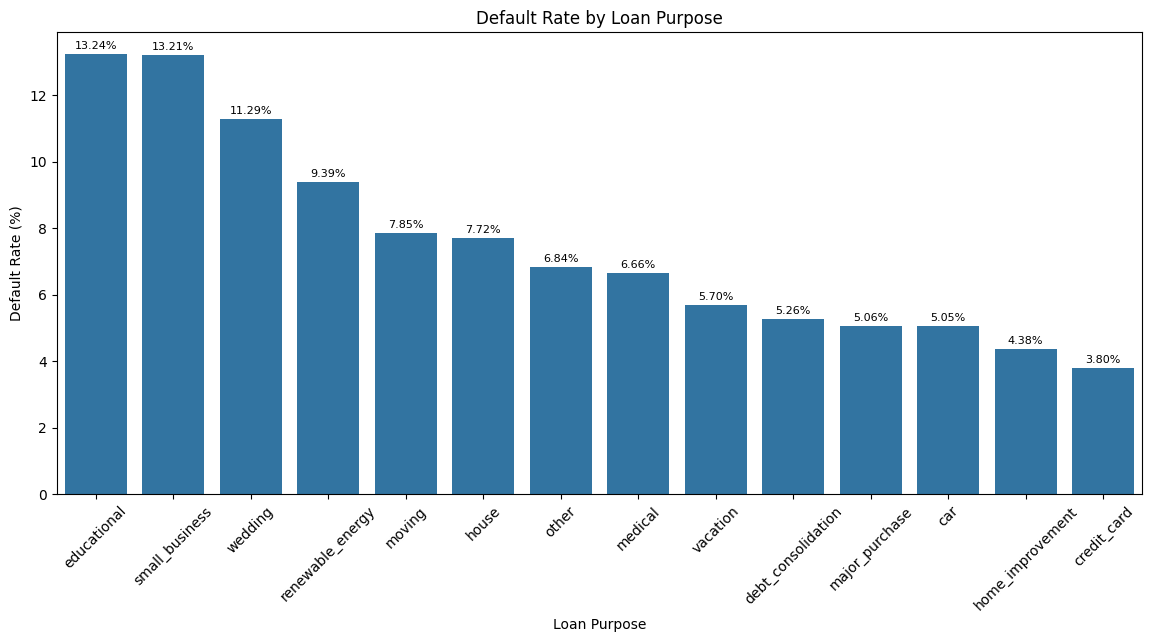

In [62]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=purpose_default,
    x='purpose',
    y='default_flag'
)

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=45)

for index, value in enumerate(purpose_default['default_flag']):
    plt.text(index, value + 0.15, f'{value:.2f}%', ha='center', fontsize=8)

plt.show()

## **Observation**

Default rates differ substantially across loan purposes. Educational (13.24%) and Small Business (13.21%) loans have the highest default rates, followed by Wedding (11.29%) and Renewable Energy (9.39%) loans. In contrast, Credit Card (3.80%) and Home Improvement (4.38%) loans exhibit the lowest default rates. This indicates that the purpose of borrowing significantly influences repayment behaviour and credit risk.

## **Insight**

The bank should apply enhanced credit screening and monitoring for Educational and Small Business loans, while lower-risk categories such as Credit Card and Home Improvement loans may provide safer lending opportunities.

## **Analysis 4: Annual Income vs Default Rate**

To analyze whether borrower income levels influence loan default risk.

## **Hypothesis**

Lower-income borrowers have higher default rates and Higher-income borrowers have lower default rates.

In [63]:
df['income_band'] = pd.cut(
    df['annual_inc'],
    bins=[0,50000,100000,150000,200000,10000000],
    labels=['<50K','50K-100K','100K-150K','150K-200K','200K+']
)

In [64]:
income_default = (
    df.groupby('income_band')['default_flag']
    .mean()
    .mul(100)
    .reset_index()
)

income_default

/tmp/ipykernel_2479/2261338353.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('income_band')['default_flag']


,income_band,default_flag
0,<50K,6.544290
1,50K-100K,4.817084
2,100K-150K,3.322526
3,150K-200K,3.092745
4,200K+,2.686763


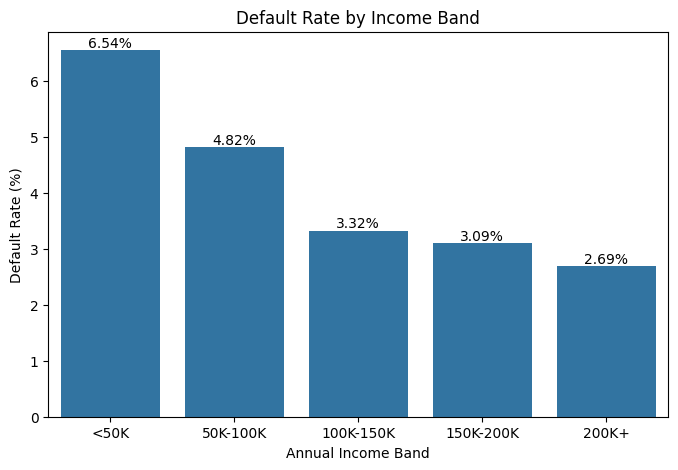

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=income_default,
    x='income_band',
    y='default_flag'
)

plt.title('Default Rate by Income Band')
plt.xlabel('Annual Income Band')
plt.ylabel('Default Rate (%)')

for index, value in enumerate(income_default['default_flag']):
    plt.text(index, value + 0.05, f'{value:.2f}%', ha='center')

plt.show()

## **Observation**

Default rates decrease consistently as annual income increases. Borrowers earning less than 50K have the highest default rate (6.54%), while borrowers earning more than 200K have the lowest default rate (2.69%). This suggests that higher-income borrowers generally possess stronger repayment capacity and lower credit risk.

## **Insight**

Lower-income borrowers represent a higher-risk segment and may require stricter credit assessment, while higher-income borrowers demonstrate stronger repayment performance and lower default risk.

## **Analysis 5: Verification Status vs Default Rate**

To analyze whether income verification status influences loan default risk

## **Hypothesis**

Verification status significantly affects default rate.

In [66]:
verification_default = (
    df.groupby('verification_status')['default_flag']
      .mean()
      .mul(100)
      .reset_index()
)

verification_default

,verification_status,default_flag
0,Not Verified,4.576621
1,Source Verified,4.169284
2,Verified,6.630753


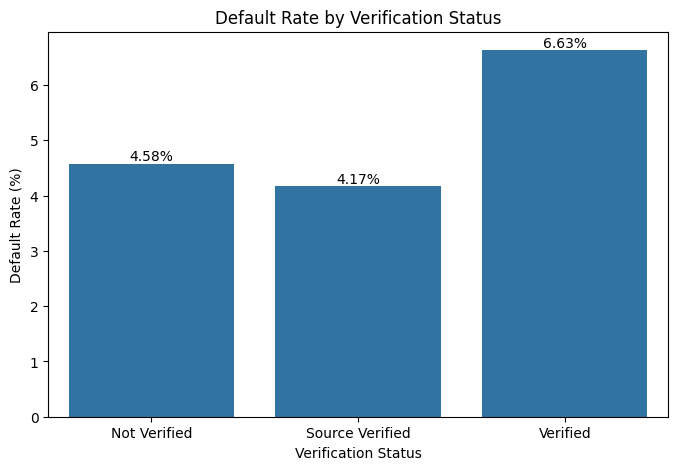

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=verification_default,
    x='verification_status',
    y='default_flag'
)

plt.title('Default Rate by Verification Status')
plt.xlabel('Verification Status')
plt.ylabel('Default Rate (%)')

for index, value in enumerate(verification_default['default_flag']):
    plt.text(index, value + 0.05, f'{value:.2f}%', ha='center')

plt.show()

## **Observation**

The default rate varies across verification statuses, with Verified borrowers showing the highest default rate (6.63%), followed by Not Verified (4.58%) and Source Verified (4.17%) borrowers.

This suggests that income verification alone does not guarantee lower default risk. In practice, higher-risk borrowers may be more likely to undergo full verification, which could explain the higher observed default rate among verified loans.

## **Insight**

Verification status should be analyzed alongside borrower risk characteristics such as loan grade, income, and DTI, as verified borrowers may already belong to higher-risk lending segments.

## **Analysis 6: DTI vs Default Rate**

To analyze whether borrowers with higher Debt-to-Income (DTI) ratios exhibit higher default rates.

## **Hypothesis**

Higher Debt-to-Income (DTI) ratios are associated with higher loan default rates.

In [68]:
df['dti_band'] = pd.cut(
    df['dti'],
    bins=[0,10,20,30,40,90],
    labels=['0-10','10-20','20-30','30-40','40+']
)

In [69]:
dti_default = (
    df.groupby('dti_band')['default_flag']
    .mean()
    .mul(100)
    .reset_index()
)

dti_default

/tmp/ipykernel_2479/2509223476.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('dti_band')['default_flag']


,dti_band,default_flag
0,0-10,4.526425
1,10-20,5.019422
2,20-30,5.756459
3,30-40,4.344870
4,40+,0.000000


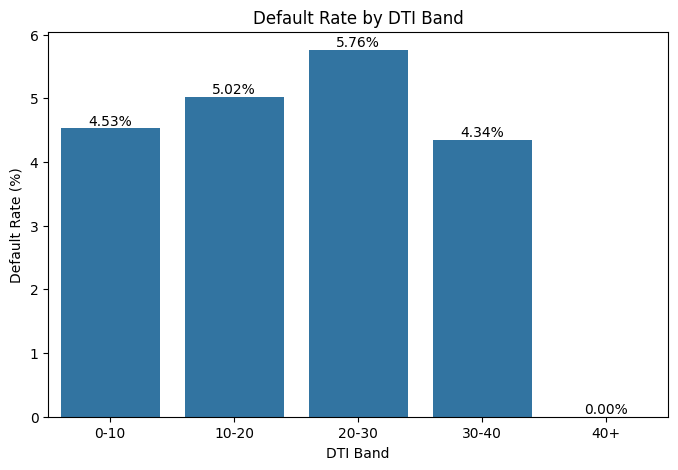

In [70]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=dti_default,
    x='dti_band',
    y='default_flag'
)

plt.title('Default Rate by DTI Band')
plt.xlabel('DTI Band')
plt.ylabel('Default Rate (%)')

for index, value in enumerate(dti_default['default_flag']):
    plt.text(index, value + 0.05, f'{value:.2f}%', ha='center')

plt.show()

## **Observation**

Default rates increase from 4.53% in the 0–10 DTI band to 5.76% in the 20–30 DTI band, suggesting that borrowers with higher debt burdens tend to exhibit higher default risk. However, the relationship weakens in the 30–40 DTI band. The 40+ DTI band contains only 79 observations (<0.01% of all loans), making its 0% default rate unreliable for interpretation. Overall, DTI appears to have a moderate influence on default behaviour.

## **Insight**

The bank should closely monitor borrowers with high DTI ratios and may consider stricter underwriting standards or enhanced risk-based pricing for high-DTI segments.

# **Multivariate Analysis**

Multivariate Analysis means analyzing the relationship between three or more variables at the same time.

## **Analysis 1: Grade & Term vs Default Rate**

To analyze how loan grade and loan term jointly influence default risk.

In [71]:
grade_term_default = pd.pivot_table(
    df,
    values='default_flag',
    index='grade',
    columns='term',
    aggfunc='mean'
) * 100

grade_term_default.round(2)

term,36,60
grade,,
A,1.77,1.54
B,3.94,2.74
C,5.55,4.35
D,8.45,6.37
E,9.57,8.53
F,12.23,12.85
G,9.33,15.16


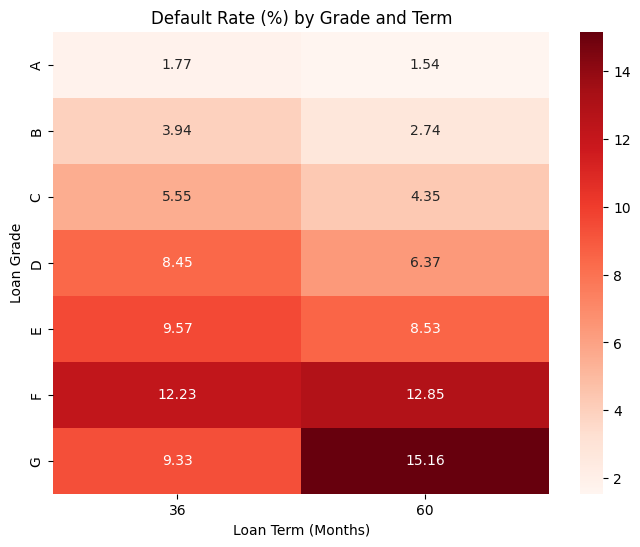

In [72]:
plt.figure(figsize=(8,6))

sns.heatmap(
    grade_term_default,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Default Rate (%) by Grade and Term')
plt.xlabel('Loan Term (Months)')
plt.ylabel('Loan Grade')

plt.show()

## **Observation**

- Default rates generally increase as loan grades move from A (lowest risk) to G (highest risk), confirming that lower credit quality borrowers are more likely to default.

- The highest default rate is observed for Grade G loans with a 60-month term (15.16%), while the lowest default rate occurs for Grade A loans with a 60-month term (1.54%).

- For Grades F and G, extending the loan term to 60 months results in noticeably higher default rates, indicating that longer repayment periods amplify risk among already high-risk borrowers.

## **Insight**

Loan grade is the strongest predictor of default risk. Banks should apply stricter approval criteria, higher pricing, or enhanced monitoring for Grade F and G borrowers, particularly on 60-month loans where default rates are highest.

## **Analysis 2: Income Bands & DTI Bands vs Default Rate**

To analyze how income level and debt burden jointly influence loan default risk and this helps identify high-risk borrower segments that may not be visible when analyzing income or DTI separately.

In [73]:
income_dti_default = pd.pivot_table(
    df,
    values='default_flag',
    index='income_band',
    columns='dti_band',
    aggfunc='mean'
) * 100

income_dti_default.round(2)

/tmp/ipykernel_2479/959212055.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  income_dti_default = pd.pivot_table(


dti_band,0-10,10-20,20-30,30-40,40+
income_band,,,,,
<50K,6.22,6.78,7.05,4.87,0.0
50K-100K,4.41,4.76,5.31,4.05,0.0
100K-150K,3.12,3.38,3.54,2.56,NaN
150K-200K,3.24,3.00,3.16,2.56,NaN
200K+,2.99,2.44,2.25,2.11,NaN


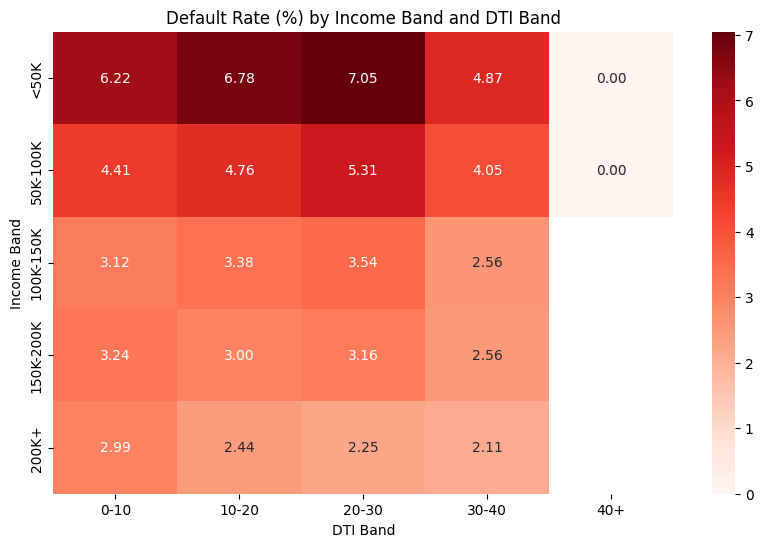

In [74]:
plt.figure(figsize=(10,6))

sns.heatmap(
    income_dti_default,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Default Rate (%) by Income Band and DTI Band')
plt.xlabel('DTI Band')
plt.ylabel('Income Band')

plt.show()

## **Observation**

- The heatmap shows a clear relationship between income level, DTI ratio, and default risk.
- Borrowers with lower income (<50K) consistently exhibit the highest default rates across all DTI bands.
- The highest observed default rate (7.05%) occurs among borrowers with income below 50K and DTI between 20–30.
- As income increases, default rates generally decrease across all DTI categories.
- Borrowers earning 200K+ show the lowest default rates, ranging from 2.11% to 2.99%.

## **Insight**

Low-income borrowers (<50K), particularly those with moderate-to-high debt burdens (DTI 10–30), represent the highest-risk segment and may require stricter credit evaluation. High-income borrowers demonstrate significantly lower default rates regardless of DTI levels.

## **Correlation Heatmap**



In [75]:
numeric_cols = [
    'loan_amnt',
    'funded_amnt',
    'int_rate',
    'annual_inc',
    'dti',
    'installment',
    'revol_bal',
    'default_flag'
]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,loan_amnt,funded_amnt,int_rate,annual_inc,dti,installment,revol_bal,default_flag
loan_amnt,1.000000,0.999263,0.145023,0.332700,0.043854,0.944977,0.333581,-0.005468
funded_amnt,0.999263,1.000000,0.145160,0.332469,0.044677,0.946005,0.333437,-0.006356
int_rate,0.145023,0.145160,1.000000,-0.072775,0.164016,0.133074,-0.035707,0.146487
annual_inc,0.332700,0.332469,-0.072775,1.000000,-0.177367,0.326185,0.295784,-0.035624
dti,0.043854,0.044677,0.164016,-0.177367,1.000000,0.029963,0.140194,0.007580
installment,0.944977,0.946005,0.133074,0.326185,0.029963,1.000000,0.316590,0.003864
revol_bal,0.333581,0.333437,-0.035707,0.295784,0.140194,0.316590,1.000000,-0.020130
default_flag,-0.005468,-0.006356,0.146487,-0.035624,0.007580,0.003864,-0.020130,1.000000


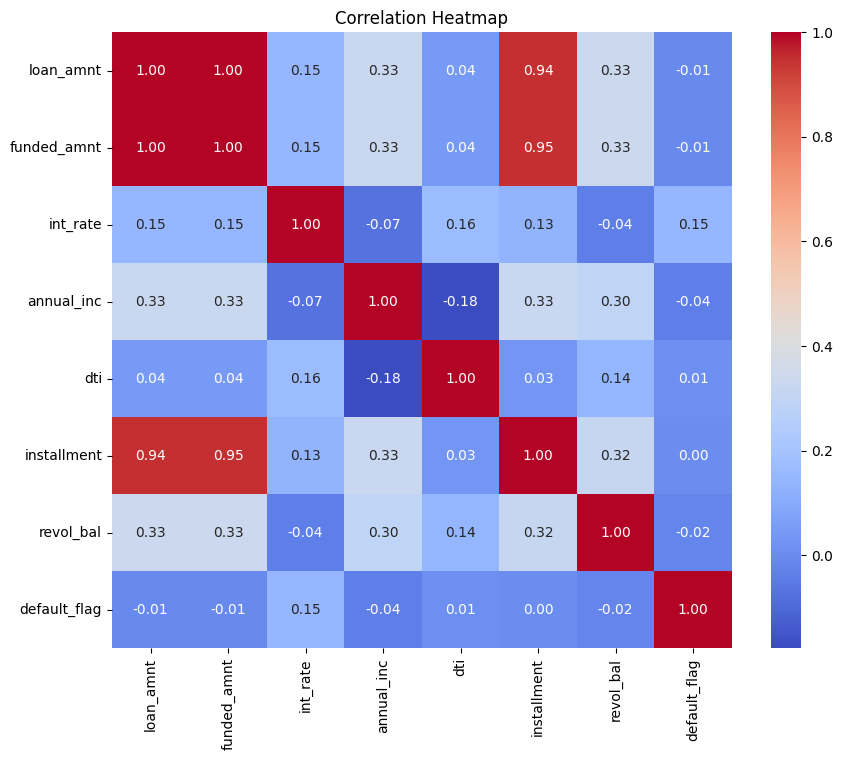

In [76]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

## **Observation**

The correlation heatmap shows that most variables have weak to moderate relationships with the default flag, indicating that loan default is influenced by multiple factors rather than a single variable.

## **Key Findings**

- Interest Rate has the strongest positive correlation with default risk (0.15), suggesting that higher-risk borrowers are charged higher interest rates and are more likely to default.
- Annual Income shows a small negative correlation with default (-0.04), indicating that higher-income borrowers tend to default less frequently.
- DTI has an almost negligible correlation with default (0.01), suggesting a weak linear relationship in the overall dataset.
- Loan Amount and Funded Amount are almost perfectly correlated (1.00), as funded amounts closely match requested loan amounts.
- Installment is highly correlated with both Loan Amount (0.94) and Funded Amount (0.95) because installment payments are directly determined by loan size.

## **Insight**

Since no single variable strongly explains default risk, lenders should rely on a combination of factors such as loan grade, interest rate, income, loan term, and borrower profile when assessing credit risk rather than using a single metric.

# **Key Takeaways**


- Loan grade is the strongest predictor of default risk, with default rates increasing from 1.77% for Grade A loans to 14.43% for Grade G loans.
- 60-month loans exhibit higher default rates (6.07%) than 36-month loans (4.68%), indicating increased risk associated with longer repayment periods.
- Default rates decrease consistently as borrower income increases, falling from 6.54% for borrowers earning less than 50K to 2.69% for borrowers earning more than 200K.
- Educational and Small Business loans show the highest default rates, suggesting that loan purpose significantly influences repayment behaviour.
- Interest rate exhibits the strongest positive correlation with default risk among the numerical variables analyzed.
- Borrowers with low income and moderate DTI levels represent the highest-risk segment in the portfolio.